##IDEA
se io apro, salvo a 10, chiudo, riapro, salvo a 10, le quantization tables sono le stesse. quindi il risultato dell'operazione di salvataggio è uguale. c'è  da capire che succede in degradazione

# Contents
In this notebook, I tried computing the quantization tables in such a way that they are compatible with the cumulative q_samples. I reapply the quantization on the previously quantized image rather than always to the original.

In [ ]:
! pip install jpegio
! pip install kornia

In [ ]:
from PIL import Image
import numpy as np
import jpegio
import matplotlib.pyplot as plt
import os
import torch
from math import pi
import kornia
from torchvision import transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi" if 'google.colab' in str(get_ipython()) else "."
sample_jpeg_path = os.path.join(BASE_DIR, "experiments/tables/reference_image/000001.jpg")
SAVE_PATH = os.path.join(BASE_DIR, "assets/quant_table_cumulative.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## computing quantization tables
Here are some trials for the qualities chosen.

In [ ]:
# qualities = [100, 25, 15, 10, 8, 7, 6, 5, 4, 3, 1]
# qualities = [100, 90, 85, 80, 75, 70, 65, 60, 55, 50]
# qualities = [100, 20, 20, 20, 20, 10, 10, 10, 5, 5]

qualities = [100, 60, 50, 30, 25, 20, 15, 12, 8, 5]

The following cell saves the quantization tables. Works cumulatively, changes just the luminance channel

In [ ]:
pil_image = Image.open(sample_jpeg_path).convert('RGB')
current_tensor = transforms.ToTensor()(pil_image).unsqueeze(0)  # [1,3,H,W] [0,1]

for i, q in enumerate(qualities):
    # RGB -> YCbCr
    ycbcr = kornia.color.rgb_to_ycbcr(current_tensor)

    # works just on Y
    y_channel = transforms.ToPILImage()(ycbcr[0, 0])  # [H,W] grayscale
    y_channel.save(f'output_img_quality_{i}.jpg', quality=q)
    y_degraded = transforms.ToTensor()(Image.open(f'output_img_quality_{i}.jpg')).unsqueeze(0)

    # image degradaded in Y -> back to YCbCr
    ycbcr_deg = ycbcr.clone()
    ycbcr_deg[:, 0] = y_degraded[:, 0]

    # YCbCr -> RGB
    current_tensor = kornia.color.ycbcr_to_rgb(ycbcr_deg).clamp(0, 1)

    # saves RGB for visualization
    transforms.ToPILImage()(current_tensor[0]).save(f'output_img_rgb_{i}.jpg')

In [ ]:
# visualization
plt.figure(figsize=(len(qualities) * 4, 5))
for i, q in enumerate(qualities):
    img = Image.open(f'output_img_rgb_{i}.jpg').convert('RGB')
    plt.subplot(1, len(qualities), i + 1)
    plt.imshow(img)
    plt.title(f'step {i}\nq={q}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# saving the tables
quant_tables = {}
for i in range(len(qualities)):
    saved_img = jpegio.read(f'output_img_quality_{i}.jpg')
    quant_tables[f'step{i}_luminance'] = torch.tensor(
        np.array(saved_img.quant_tables[0], dtype=np.float32)
    )

torch.save(quant_tables, SAVE_PATH)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
current_img = pil_image
for i, q in enumerate(qualities):
    current_img.save(f'output_img_quality_{i}.jpg', quality=q)
    current_img = Image.open(f'output_img_quality_{i}.jpg').convert('RGB')

printing quantization tables

In [ ]:
num_images = len(qualities)

for i in range(num_images):
    filename = f'output_img_quality_{i}.jpg'
    try:
        saved_img = jpegio.read(filename)
        # Check if saved_img and its quant_tables attribute are not None
        if saved_img is not None and saved_img.quant_tables is not None:
            print(f"--- Quantization Tables for Quality {qualities[i]} (index {i}) ---")
            for table_idx, quant_table in enumerate(saved_img.quant_tables):
                print(f"Table {table_idx}:\n{quant_table}")
        else:
            print(f"Warning: Could not read or access quantization tables for {filename}. saved_img: {saved_img}")
    except Exception as e:
        print(f"Error reading {filename}: {e}")

--- Quantization Tables for Quality 100 (index 0) ---
Table 0:
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]]
Table 1:
[[1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1]]
--- Quantization Tables for Quality 60 (index 1) ---
Table 0:
[[13  9  8 13 19 32 41 49]
 [10 10 11 15 21 46 48 44]
 [11 10 13 19 32 46 55 45]
 [11 14 18 23 41 70 64 50]
 [14 18 30 45 54 87 82 62]
 [19 28 44 51 65 83 90 74]
 [39 51 62 70 82 97 96 81]
 [58 74 76 78 90 80 82 79]]
Table 1:
[[14 14 19 38 79 79 79 79]
 [14 17 21 53 79 79 79 79]
 [19 21 45 79 79 79 79 79]
 [38 53 79 79 79 79 79 79]
 [79 79 79 79 79 79 79 79]
 [79 79 79 79 79 79 79 79]
 [79 79 79 79 79 79 79 79]
 [79 79 79 79 79 79 79 79]]
--- Quantization Tables for Quality 50 (index 2) ---
Table 0:
[[ 16  11  10  16  24  40  51  61]
 [ 12  12  14  19  2

# saving quantization tables

### pt

In [ ]:
quant_tables = {}
for i in range(len(qualities)):
    saved_img = jpegio.read(f'output_img_quality_{i}.jpg')
    quant_tables[f'step{i}_luminance'] = torch.tensor(
        np.array(saved_img.quant_tables[0], dtype=np.float32)
    )
    quant_tables[f'step{i}_chrominance'] = torch.tensor(
        np.array(saved_img.quant_tables[1], dtype=np.float32)
    )

torch.save(quant_tables, SAVE_PATH)

Verying that the tables shave been properly saved:

In [ ]:
quant_tables = torch.load(SAVE_PATH)

# Accesso diretto, già tensori
lum = quant_tables['step10_luminance']#.to('cuda')
chrom = quant_tables['step10_chrominance']#.to('cuda')

In [ ]:
print(f"Luminance:\n{lum}")
print(f"Chrominance:\n{chrom}")

## Trial with jpeg degradation

In [ ]:
! pip install torch-dct

In [ ]:
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [ ]:
def get_quant_tables(step, device):
    lum = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def jpeg_degradation(img_batch, step):
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step
    if current_step == 0:
        return img_batch

    B, C, H, W = img_batch.shape
    lum, _ = get_quant_tables(current_step, device)

    # [-1,1] -> [0,1] for kornia
    x = (img_batch + 1) * 0.5

    # Store original dimensions for cropping later
    orig_H, orig_W = H, W

    # Pad image to be a multiple of 8
    pad_H = (8 - H % 8) % 8
    pad_W = (8 - W % 8) % 8
    # pad (left, right, top, bottom)
    x = F.pad(x, (0, pad_W, 0, pad_H), mode='reflect') # Using 'reflect' for better boundary handling

    _, _, H_padded, W_padded = x.shape

    # RGB -> YCbCr  (output [0,1])
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)

    # [0,1] -> [0,255]
    x_255 = x_ycbcr * 255.0

    # Unfold into 8x8 blocks. Now H_padded and W_padded are multiples of 8.
    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)
    bH, bW = blocks.shape[2], blocks.shape[3] # bH = H_padded // 8, bW = W_padded // 8
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)

    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')

    q = lum.unsqueeze(0).unsqueeze(0)  # [1, 1, 8, 8]
    # Apply quantization only to Y channel (index 0 for YCbCr)
    dct_blocks[:, 0] = torch.round(dct_blocks[:, 0] / q) * q

    result_flat = dct.idct_2d(dct_blocks, norm='ortho')

    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    # Reconstruct using padded dimensions
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H_padded, W_padded)

    # Crop back to original dimensions
    result = result[:, :, :orig_H, :orig_W]

    # [0,255] -> [0,1] -> RGB -> [-1,1]
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

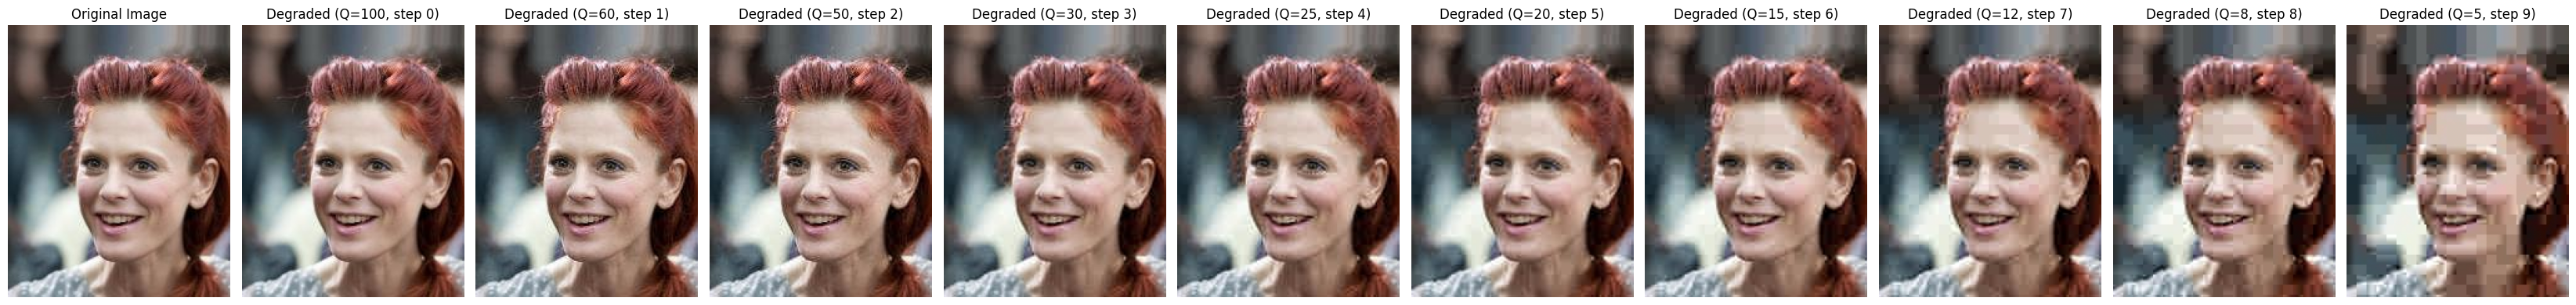

In [ ]:
# Convert pil_image to a PyTorch tensor, normalize to [-1, 1]
preprocess = transforms.Compose([
    transforms.ToTensor(), # Converts PIL Image to Tensor, scales to [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Scales to [-1, 1]
])
original_tensor = preprocess(pil_image).unsqueeze(0) # Add batch dimension: [1, C, H, W]

# Choose a step (index from the 'qualities' list) for degradation
degradation_steps = list(range(len(qualities))) # Include all qualities

plt.figure(figsize=((len(degradation_steps) + 1) * 3, 5))

# Display original image
plt.subplot(1, len(degradation_steps) + 1, 1)
plt.imshow(pil_image)
plt.title('Original Image')
plt.axis('off')

for i, step_idx in enumerate(degradation_steps):
    # Call jpeg_degradation
    # The jpeg_degradation function expects a tensor for 'step'
    degraded_tensor = jpeg_degradation(original_tensor, torch.tensor(step_idx, dtype=torch.long))

    # Denormalize from [-1, 1] to [0, 1]
    display_tensor = (degraded_tensor.squeeze(0) * 0.5) + 0.5
    # Convert the degraded tensor back to a PIL image for display
    degraded_pil_image = transforms.ToPILImage()(display_tensor)

    # Display the degraded image
    plt.subplot(1, len(degradation_steps) + 1, i + 2)
    plt.imshow(degraded_pil_image)
    plt.title(f'Degraded (Q={qualities[step_idx]}, step {step_idx})')
    plt.axis('off')

plt.tight_layout()
plt.show()

As already discovered, jpeg degradation is not cumulative, so, as expected, it does not perform escalated degradation. Now a confirm from the cumulative `q_sample` function.

In [ ]:
! pip install torchgeometry

In [ ]:
import sys
import os
import torch
from torchvision import transforms

# Add the custom module directory to sys.path
custom_module_path = os.path.join(BASE_DIR, "src/Cold-Diffusion-Models/resolution-diffusion-pytorch/resolution_diffusion_pytorch")
if custom_module_path not in sys.path:
    sys.path.insert(0, custom_module_path)

sys.argv = ['colab_kernel_launcher.py']

from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

# Set device to CPU explicitly
DEVICE = 'cpu'
print(f"Using device: {DEVICE}")

IMG_SIZE = 128

train_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1) # Normalize to [-1,1] for diffusion
])

from torch._prims_common import check
# --- CONFIGURATION ---
class Args:
    time_steps = 10
    train_steps = 2000
    save_folder = BASE_DIR
    data_path = BASE_DIR
    checkpoint_path = BASE_DIR
    load_path =BASE_DIR
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).to(DEVICE)

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = DEVICE,
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).to(DEVICE)

class DummyWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.module = model

    def forward(self, *args, **kwargs):
        return self.module(*args, **kwargs)

    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.module, name)

if not isinstance(diffusion, torch.nn.DataParallel):
    diffusion = DummyWrapper(diffusion)
    print("DummyWrapper aggiornato")

# --- OVERWRITING ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

Using device: cpu
Is Time embed used ?  True
DummyWrapper aggiornato


Degradation (DCT)...
Range image: [-1.0, 1.0]


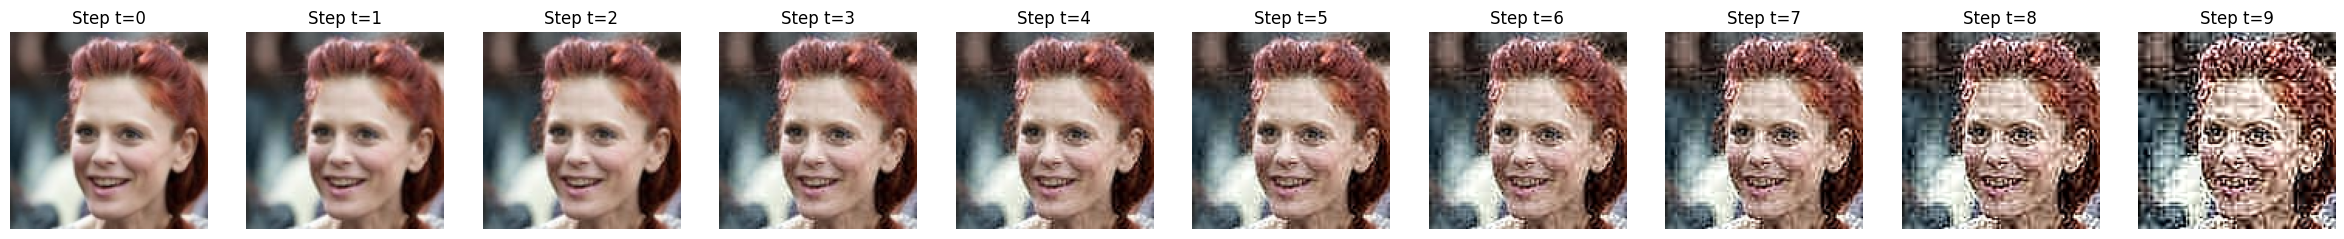

In [ ]:
def show_degradation(img_path, steps_to_show):
    x_0_pil = Image.open(img_path)

    x_0_processed = train_transform(x_0_pil)
    x_0 = x_0_processed.unsqueeze(0).to(DEVICE)

    n_steps = len(steps_to_show)
    inner_model = diffusion

    # --- DEGRADATION ---
    print("Degradation (DCT)...")
    fig, axs = plt.subplots(1, n_steps, figsize=(30, 10))
    print(f"Range image: [{x_0.min()}, {x_0.max()}]")
    for i, t in enumerate(steps_to_show):
        with torch.no_grad():
            x_t = inner_model.q_sample(x_0, torch.tensor([t], device=DEVICE))

        # From [-1, 1] to [0, 1] for visualization
        img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
        axs[i].imshow(img_vis.clip(0, 1))
        axs[i].set_title(f"Step t={t}")
        axs[i].axis('off')
    plt.show()


steps_to_show = [i for i in range(10)]
show_degradation(sample_jpeg_path, steps_to_show)

## exploring another option
I set the quantization tables to multiples of one another.

First option: costnant increase for the values.

In [ ]:
# print("--- Base Quantization Table (Quality 50 / Step 2 Luminance) ---")
# base_quant_table_luminance = quant_tables['step2_luminance']
# base_quant_table_chrominance = quant_tables['step2_chrominance'] # Get base chrominance table for consistency
# print(base_quant_table_luminance)

# initial_increase_step = 15 # Starting increase factor
# num_steps = 10

# global generated_quant_tables_dict # Declare as global to be accessible by other cells
# generated_quant_tables_dict = {}

# for i in range(num_steps):
#     current_increase = initial_increase_step * (i + 1)

#     # Create new luminance table with clipping
#     quant_table_luminance_new = (base_quant_table_luminance + current_increase).clamp(0, 255)
#     # Create new chrominance table, similarly increased and clipped
#     quant_table_chrominance_new = (base_quant_table_chrominance + current_increase).clamp(0, 255)

#     generated_quant_tables_dict[f'step{i}_luminance'] = quant_table_luminance_new
#     generated_quant_tables_dict[f'step{i}_chrominance'] = quant_table_chrominance_new

#     print(f"\n--- Generated Quantization Table for Step {i} (Luminance, Increase by +{current_increase}) ---")
#     print(quant_table_luminance_new)

Second option: costant multiplication.

In [ ]:
print("--- Base Quantization Table (Quality 50 / Step 2 Luminance) ---")
base_quant_table_luminance = quant_tables['step2_luminance']
base_quant_table_chrominance = quant_tables['step2_chrominance'] # Get base chrominance table for consistency
print(base_quant_table_luminance)

initial_increase_step = 1.5 # Starting increase factor
num_steps = 10

global generated_quant_tables_dict
generated_quant_tables_dict = {}

for i in range(num_steps):
    current_increase = initial_increase_step * (i + 1)

    # Create new luminance table with clipping
    quant_table_luminance_new = (base_quant_table_luminance * current_increase).clamp(0, 255)
    # Create new chrominance table, similarly increased and clipped
    quant_table_chrominance_new = (base_quant_table_chrominance + current_increase).clamp(0, 255)

    generated_quant_tables_dict[f'step{i}_luminance'] = quant_table_luminance_new
    generated_quant_tables_dict[f'step{i}_chrominance'] = quant_table_chrominance_new

    print(f"\n--- Generated Quantization Table for Step {i} (Luminance, Increase by +{current_increase}) ---")
    print(quant_table_luminance_new)

--- Base Quantization Table (Quality 50 / Step 2 Luminance) ---
tensor([[ 16.,  11.,  10.,  16.,  24.,  40.,  51.,  61.],
        [ 12.,  12.,  14.,  19.,  26.,  58.,  60.,  55.],
        [ 14.,  13.,  16.,  24.,  40.,  57.,  69.,  56.],
        [ 14.,  17.,  22.,  29.,  51.,  87.,  80.,  62.],
        [ 18.,  22.,  37.,  56.,  68., 109., 103.,  77.],
        [ 24.,  35.,  55.,  64.,  81., 104., 113.,  92.],
        [ 49.,  64.,  78.,  87., 103., 121., 120., 101.],
        [ 72.,  92.,  95.,  98., 112., 100., 103.,  99.]])

--- Generated Quantization Table for Step 0 (Luminance, Increase by +1.5) ---
tensor([[ 24.0000,  16.5000,  15.0000,  24.0000,  36.0000,  60.0000,  76.5000,
          91.5000],
        [ 18.0000,  18.0000,  21.0000,  28.5000,  39.0000,  87.0000,  90.0000,
          82.5000],
        [ 21.0000,  19.5000,  24.0000,  36.0000,  60.0000,  85.5000, 103.5000,
          84.0000],
        [ 21.0000,  25.5000,  33.0000,  43.5000,  76.5000, 130.5000, 120.0000,
          93.000

In [ ]:
import torch_dct as dct

def get_custom_quant_tables(step, device):
    global generated_quant_tables_dict

    # Ensure the step exists in the generated tables
    if f'step{step}_luminance' not in generated_quant_tables_dict:
        raise ValueError(f"Quantization table for step {step} not found in generated_quant_tables_dict.")

    lum = generated_quant_tables_dict[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = generated_quant_tables_dict[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def jpeg_degradation2(img_batch, step):
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step
    if current_step == 0:
        return img_batch

    B, C, H, W = img_batch.shape
    lum, _ = get_custom_quant_tables(current_step, device)

    # [-1,1] -> [0,1] for kornia
    x = (img_batch + 1) * 0.5

    # Store original dimensions for cropping later
    orig_H, orig_W = H, W

    # Pad image to be a multiple of 8
    pad_H = (8 - H % 8) % 8
    pad_W = (8 - W % 8) % 8
    # pad (left, right, top, bottom)
    x = F.pad(x, (0, pad_W, 0, pad_H), mode='reflect')

    _, _, H_padded, W_padded = x.shape

    # RGB -> YCbCr  (output [0,1])
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)

    # [0,1] -> [0,255]
    x_255 = x_ycbcr * 255.0

    # Unfold into 8x8 blocks. Now H_padded and W_padded are multiples of 8.
    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)
    bH, bW = blocks.shape[2], blocks.shape[3] # bH = H_padded // 8, bW = W_padded // 8
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)

    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')

    q = lum.unsqueeze(0).unsqueeze(0)  # [1, 1, 8, 8]

    # Apply quantization only to Y channel (index 0 for YCbCr)
    dct_blocks[:, 0] = torch.round(dct_blocks[:, 0] / q) * q

    result_flat = dct.idct_2d(dct_blocks, norm='ortho')

    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    # Reconstruct using padded dimensions
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H_padded, W_padded)

    # Crop back to original dimensions
    result = result[:, :, :orig_H, :orig_W]

    # [0,255] -> [0,1] -> RGB -> [-1,1]
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

In [ ]:
# --- OVERWRITING ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpeg_degradation2(img, s) for i in range(args.time_steps)]

Degradation (DCT)...
Range image: [-1.0, 1.0]


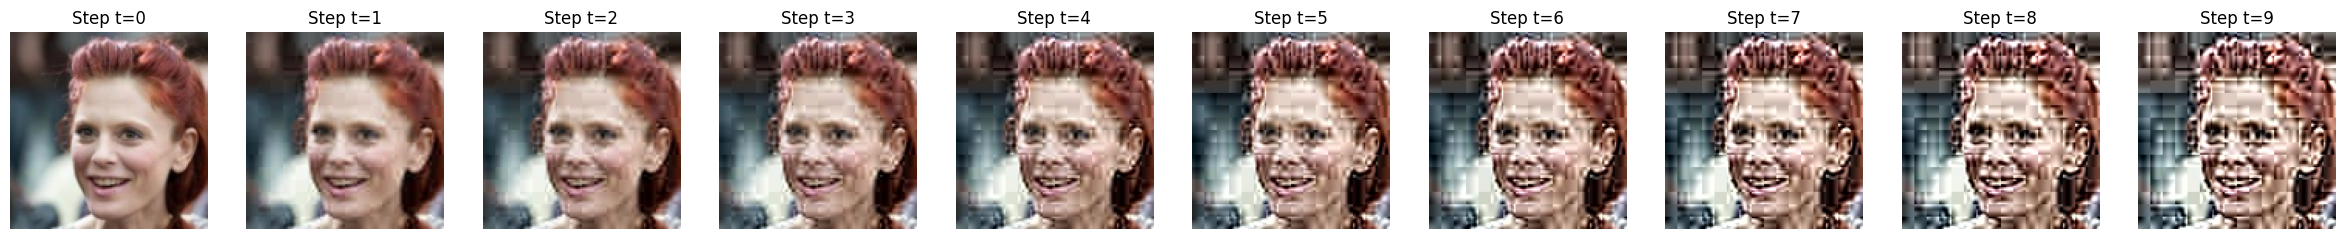

In [ ]:
def show_degradation(img_path, steps_to_show):
    x_0_pil = Image.open(img_path)

    x_0_processed = train_transform(x_0_pil)
    x_0 = x_0_processed.unsqueeze(0).to(DEVICE)

    n_steps = len(steps_to_show)
    inner_model = diffusion

    # --- DEGRADATION ---
    print("Degradation (DCT)...")
    fig, axs = plt.subplots(1, n_steps, figsize=(30, 10))
    print(f"Range image: [{x_0.min()}, {x_0.max()}]")
    for i, t in enumerate(steps_to_show):
        with torch.no_grad():
            x_t = inner_model.q_sample(x_0, torch.tensor([t], device=DEVICE))

        # From [-1, 1] to [0, 1] for visualization
        img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
        axs[i].imshow(img_vis.clip(0, 1))
        axs[i].set_title(f"Step t={t}")
        axs[i].axis('off')
    plt.show()


steps_to_show = [i for i in range(10)]
show_degradation(sample_jpeg_path, steps_to_show)

The result is very similar to before. To remain truthful, the previous version will be used in further experiments.